In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/ExampleCode/Input/00.05.csv")
AfterPulse = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/RawFile/AfterPulse.csv")
AfterPulse

,range_m,afterpulse_counts_per_bin,afterpulse_raw
0,0.00,0.0,0.0
1,3.75,0.0,0.0
2,7.50,0.0,0.0
3,11.25,0.0,0.0
4,15.00,0.0,0.0
...,...,...,...
4495,16856.25,NaN,NaN
4496,16860.00,NaN,NaN
4497,16863.75,NaN,NaN
4498,16867.50,NaN,NaN


In [2]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 10001.25,
    "bg_end_m": 14996.25,
    "bg_start_m_3to5km": 3000,
    "bg_end_m_3to5km": 5621.25,
    "bg_start_m_10to15km": 10001.25,
    "bg_end_m_10to15km": 14996.25,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "min_toggle_rate": 0.5,
    "max_toggle_rate": 10,
    "deadtime_region_begin": 0,
    "deadtime_region_end": 1500,
    "Number_of_pulse": 2400,
}


In [3]:
# add bin no. and bin_spacing 
bin_spacing_m = 3.75
range_m = 2000

# add bin_index (0, 1, 2, ...)
df.insert(0, "bin_index", np.arange(len(df)))

# add range_m (0, 3.75, 7.5, ...)
df.insert(1, "range_m", df["bin_index"] * bin_spacing_m)

# df["analog_sterr"] = df["analog_sterr"] / np.sqrt(config["Number_of_pulse"])
# df["pc_sterr"] = df["pc_sterr"] / np.sqrt(config["Number_of_pulse"])

#find signal to noise ratio
df["SNR_analog"] = df["analog"] / df["analog_sterr"]
df["SNR_Photon"] = df["photon_counting"] / df["pc_sterr"]

#Change MHz to Photon_per_bin
df["photon_per_bin"] = df["photon_counting"] * config["bin_width_ns"] * 1e-3

print(df.head())

   bin_index  range_m    analog  analog_sterr  photon_counting  pc_sterr  \
0          0     0.00   32.5068      0.186314        170.28000  0.887414   
1          1     3.75   72.2066      0.364441        195.29500  0.882275   
2          2     7.50  267.2780      2.211960        119.36400  1.323580   
3          3    11.25  473.4230      0.081785          1.67434  0.167204   
4          4    15.00  473.4570      0.000000          0.00000  0.000000   

   overflow_info   SNR_analog  SNR_Photon  photon_per_bin  
0            0.0   174.473201  191.883383        4.257000  
1            0.0   198.129738  221.353886        4.882375  
2            0.0   120.833107   90.182686        2.984100  
3            0.0  5788.600410   10.013756        0.041858  
4            0.0          inf         NaN        0.000000  


In [4]:
df_around_10km = df[df["range_m"].between(14995, 15100)]
df_around_10km[["bin_index", "range_m", "analog", "photon_per_bin"]].head(10)


,bin_index,range_m,analog,photon_per_bin
3999,3999,14996.25,3.95486,0.00293


In [5]:
#Need to cut data from 1500+
#df_0_1500 is data from 0-1500
df_0_5000 = df[(df["range_m"] >= 0) & (df["range_m"] <= 5000)]
#AfterPulse = AfterPulse[(AfterPulse["range_m"] >= 0) & (AfterPulse["range_m"] <= 1500)]

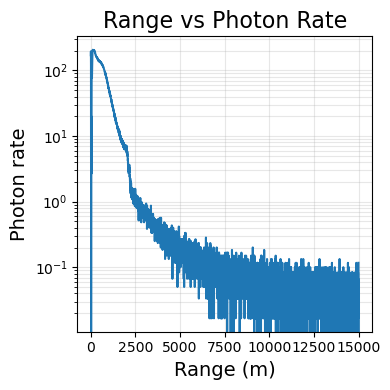

In [6]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])
    
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()

#plot PhotonRate vs Range
plot_xy(
    df,
    xcol="range_m",
    ycol="photon_counting",
    yscale="log",
    title="Range vs Photon Rate",
    xlabel="Range (m)",
    ylabel="Photon rate",
    outfile="RawFilePicforExample/Prototype/range_vs_photon_rate.png",
)

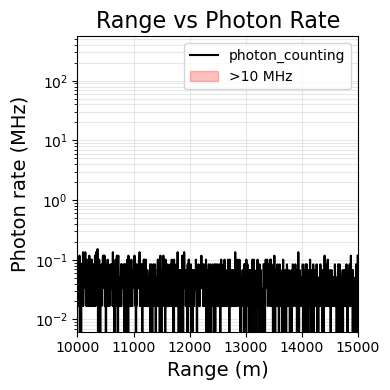

In [7]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    plt.figure(figsize=figsize)

    # main curve
    plt.plot(df[xcol], df[ycol], color="black", lw=1.5, label=ycol)

    # scales FIRST (important for ylim)
    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.xlim(10000, 15000)

    # get y-limits AFTER scale
    y_min, y_max = plt.ylim()

    # ---- Highlight regions ----
    # 0.5–10 MHz
    # mask_valid = df["photon_counting"].between(0.5, 10)
    # plt.fill_between(
    #     df[xcol],
    #     y_min,
    #     y_max,
    #     where=mask_valid,
    #     color="orange",
    #     alpha=0.3,
    #     label="0.5–10 MHz",
    # )

    # >10 MHz
    mask_high = df["photon_counting"] > 10
    plt.fill_between(
        df[xcol],
        y_min,
        y_max,
        where=mask_high,
        color="red",
        alpha=0.25,
        label=">10 MHz",
    )

    # labels
    plt.xlabel(xlabel or xcol, fontsize=14)
    plt.ylabel(ylabel or ycol, fontsize=14)
    plt.title(title or f"{ycol} vs {xcol}", fontsize=16)

    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()

plot_xy(
    df,
    xcol="range_m",
    ycol="photon_counting",
    yscale="log",
    title="Range vs Photon Rate",
    xlabel="Range (m)",
    ylabel="Photon rate (MHz)",
    outfile="RawFilePicforExample/Prototype/range_vs_photon_rate.png",
)


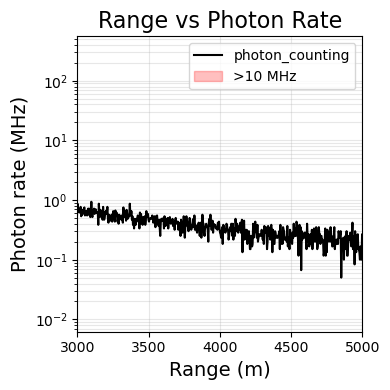

In [8]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    plt.figure(figsize=figsize)

    # main curve
    plt.plot(df[xcol], df[ycol], color="black", lw=1.5, label=ycol)

    # scales FIRST (important for ylim)
    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.xlim(3000, 5000)

    # get y-limits AFTER scale
    y_min, y_max = plt.ylim()

    # ---- Highlight regions ----
    # 0.5–10 MHz
    # mask_valid = df["photon_counting"].between(0.5, 10)
    # plt.fill_between(
    #     df[xcol],
    #     y_min,
    #     y_max,
    #     where=mask_valid,
    #     color="orange",
    #     alpha=0.3,
    #     label="0.5–10 MHz",
    # )

    # >10 MHz
    mask_high = df["photon_counting"] > 10
    plt.fill_between(
        df[xcol],
        y_min,
        y_max,
        where=mask_high,
        color="red",
        alpha=0.25,
        label=">10 MHz",
    )

    # labels
    plt.xlabel(xlabel or xcol, fontsize=14)
    plt.ylabel(ylabel or ycol, fontsize=14)
    plt.title(title or f"{ycol} vs {xcol}", fontsize=16)

    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()

plot_xy(
    df,
    xcol="range_m",
    ycol="photon_counting",
    yscale="log",
    title="Range vs Photon Rate",
    xlabel="Range (m)",
    ylabel="Photon rate (MHz)",
    outfile="RawFilePicforExample/Prototype/range_vs_photon_rate.png",
)


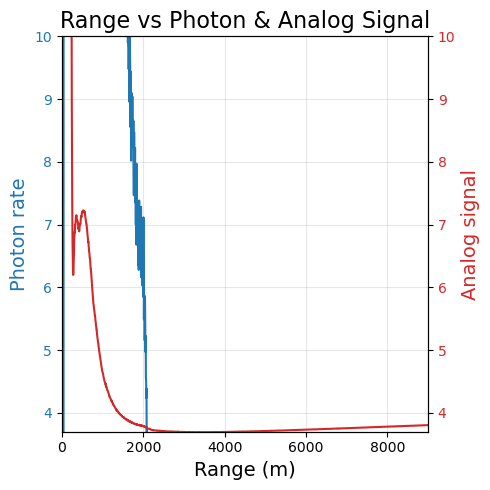

In [9]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_ylim(3.7, 10)       # tune for photon
ax2.set_ylim(3.7, 10) # tune for analog
ax1.set_xlim(0, 9000)       # tune for photon
ax2.set_xlim(0, 9000) # tune for analog

plt.savefig("RawFilePicforExample/Prototype/RangevsAnalogInput.png", dpi=300)
plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


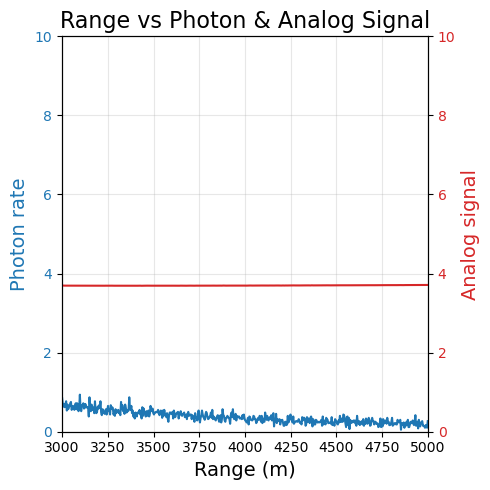

In [10]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_0_5000["range_m"], df_0_5000["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_0_5000["range_m"], df_0_5000["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_ylim(0, 10)       # tune for photon
ax2.set_ylim(0, 10) # tune for analog
ax1.set_xlim(3000, 5000)       # tune for photon
ax2.set_xlim(3000, 5000) # tune for analog

plt.savefig("RawFilePicforExample/Prototype/RangevsAnalogInput.png", dpi=300)
plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [11]:
# -----------------------------
# Background windows
# -----------------------------
bg_row_3to5km = df[
    (df["range_m"] >= config["bg_start_m_3to5km"]) &
    (df["range_m"] <= config["bg_end_m_3to5km"])
]

bg_row_10to15km = df[
    (df["range_m"] >= config["bg_start_m_10to15km"]) &
    (df["range_m"] <= config["bg_end_m_10to15km"])
]

# -----------------------------
# Means
# -----------------------------
Analog_bg_mean_3to5km = bg_row_3to5km["analog"].mean()
Photon_bg_mean_3to5km = bg_row_3to5km["photon_per_bin"].mean()

Analog_bg_mean_10to15km = bg_row_10to15km["analog"].mean()
Photon_bg_mean_10to15km = bg_row_10to15km["photon_per_bin"].mean()

# -----------------------------
# Noise (standard deviation)
# -----------------------------
Analog_bg_std_3to5km = bg_row_3to5km["analog"].std()
Photon_bg_std_3to5km = bg_row_3to5km["photon_per_bin"].std()

Analog_bg_std_10to15km = bg_row_10to15km["analog"].std()
Photon_bg_std_10to15km = bg_row_10to15km["photon_per_bin"].std()

# -----------------------------
# Combined noise
# -----------------------------
Analog_sigma_combined = np.sqrt(
    Analog_bg_std_3to5km**2 + Analog_bg_std_10to15km**2
)

Photon_sigma_combined = np.sqrt(
    Photon_bg_std_3to5km**2 + Photon_bg_std_10to15km**2
)

# -----------------------------
# Stability check
# -----------------------------
k = 2  # 2-sigma criterion (recommended)

Analog_stable = abs(Analog_bg_mean_3to5km - Analog_bg_mean_10to15km) < k * Analog_sigma_combined
Photon_stable = abs(Photon_bg_mean_3to5km - Photon_bg_mean_10to15km) < k * Photon_sigma_combined

# -----------------------------
# Report
# -----------------------------
print("===== BACKGROUND MEAN =====")
print(f"Analog  3–5 km  : {Analog_bg_mean_3to5km:.6f}")
print(f"Analog 10–15 km : {Analog_bg_mean_10to15km:.6f}")
print(f"Photon  3–5 km : {Photon_bg_mean_3to5km:.6e}")
print(f"Photon 10–15 km: {Photon_bg_mean_10to15km:.6e}")

print("\n===== BACKGROUND NOISE (STD) =====")
print(f"Analog  3–5 km  σ: {Analog_bg_std_3to5km:.6f}")
print(f"Analog 10–15 km σ: {Analog_bg_std_10to15km:.6f}")
print(f"Photon  3–5 km  σ: {Photon_bg_std_3to5km:.6e}")
print(f"Photon 10–15 km σ: {Photon_bg_std_10to15km:.6e}")

print("\n===== STABILITY CHECK =====")
print(f"Analog stable (|Δbg| < {k}σ): {Analog_stable}")
print(f"Photon stable (|Δbg| < {k}σ): {Photon_stable}")


===== BACKGROUND MEAN =====
Analog  3–5 km  : 3.703248
Analog 10–15 km : 3.892404
Photon  3–5 km : 8.087664e-03
Photon 10–15 km: 1.104712e-03

===== BACKGROUND NOISE (STD) =====
Analog  3–5 km  σ: 0.009695
Analog 10–15 km σ: 0.036327
Photon  3–5 km  σ: 4.082618e-03
Photon 10–15 km σ: 6.932373e-04

===== STABILITY CHECK =====
Analog stable (|Δbg| < 2σ): False
Photon stable (|Δbg| < 2σ): True


In [12]:
#Find Background for Photon per Bin Rate and Analog Signal
bg_row = df[(df["range_m"] >= config["bg_start_m"]) & (df["range_m"] <= config["bg_end_m"])]

Analog_bg_mean = bg_row["analog"].mean()
Photon_bg_mean = bg_row["photon_per_bin"].mean()

#Show Background value
print("Analog background (mean):", Analog_bg_mean)
print("Photon Per Bin background (mean):", Photon_bg_mean)

Analog background (mean): 3.8924044261065265
Photon Per Bin background (mean): 0.0011047123818454614


In [13]:
df["analog_bg_corr"] = df["analog"] - Analog_bg_mean
df["Photon_per_bin_bg_corr"] = df["photon_per_bin"] - Photon_bg_mean

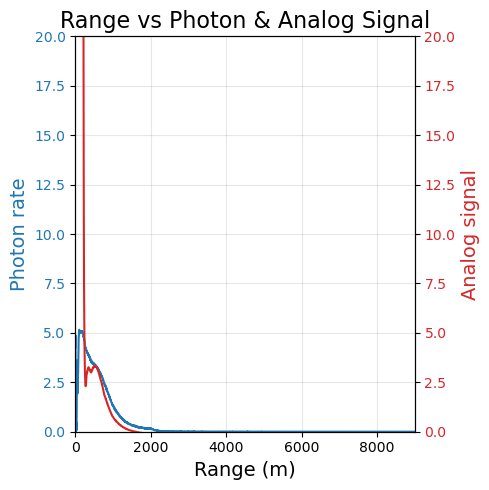

In [14]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["Photon_per_bin_bg_corr"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog_bg_corr"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_ylim(0, 20)       # tune for photon
ax2.set_ylim(0, 20) # tune for analog
ax1.set_xlim(0, 9000)       # tune for photon
ax2.set_xlim(0, 9000) # tune for analog

plt.savefig("RawFilePicforExample/Prototype/RangevsAnalogInput.png", dpi=300)
plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [15]:
df["afterpulse_raw"] = AfterPulse["afterpulse_raw"]
df["afterpulse_counts_per_bin"] = df["afterpulse_raw"] * config["bin_width_ns"] * 1e-3
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,analog_bg_corr,Photon_per_bin_bg_corr,afterpulse_raw,afterpulse_counts_per_bin
0,0,0.00,32.50680,0.186314,170.280000,0.887414,0.0,174.473201,191.883383,4.257000,28.614396,4.255895,0.0,0.0
1,1,3.75,72.20660,0.364441,195.295000,0.882275,0.0,198.129738,221.353886,4.882375,68.314196,4.881270,0.0,0.0
2,2,7.50,267.27800,2.211960,119.364000,1.323580,0.0,120.833107,90.182686,2.984100,263.385596,2.982995,0.0,0.0
3,3,11.25,473.42300,0.081785,1.674340,0.167204,0.0,5788.600410,10.013756,0.041858,469.530596,0.040754,0.0,0.0
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,469.564596,-0.001105,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,3.95379,0.000000,0.033487,0.000000,0.0,inf,inf,0.000837,0.061386,-0.000268,NaN,NaN
3996,3996,14985.00,3.95427,0.000000,0.066974,0.000000,0.0,inf,inf,0.001674,0.061866,0.000570,NaN,NaN
3997,3997,14988.75,3.95419,0.000000,0.050230,0.000000,0.0,inf,inf,0.001256,0.061786,0.000151,NaN,NaN
3998,3998,14992.50,3.95484,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.062436,-0.001105,NaN,NaN


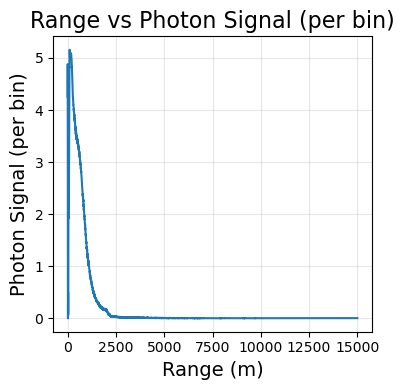

In [16]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()
plot_xy(
    df,
    xcol="range_m",
    ycol="photon_per_bin",
    yscale="linear",
    title="Range vs Photon Signal (per bin)",
    xlabel="Range (m)",
    ylabel="Photon Signal (per bin)",
    outfile="RawFilePicforExample/Prototype/range_vs_Photon_Signal_per_bin.png",
)

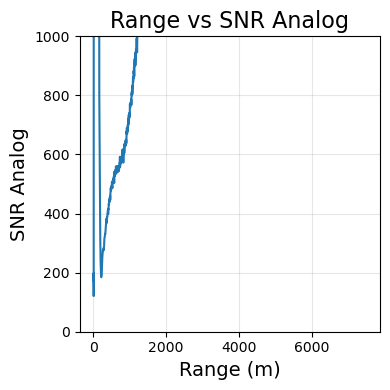

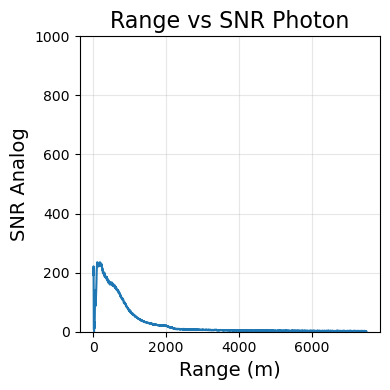

In [17]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)
    plt.ylim(0,1000)
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()
plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_analog",
    yscale="linear",
    title="Range vs SNR Analog",
    xlabel="Range (m)",
    ylabel="SNR Analog",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_SNR.png",
)
plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_Photon",
    yscale="linear",
    title="Range vs SNR Photon",
    xlabel="Range (m)",
    ylabel="SNR Analog",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_SNR.png",
)

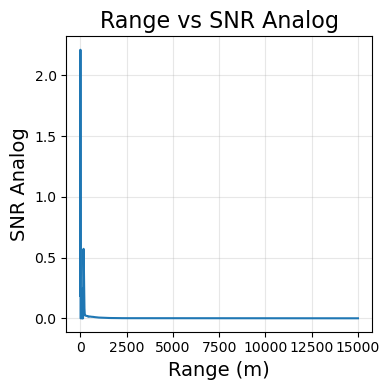

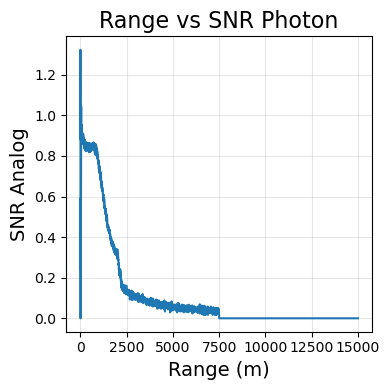

In [18]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)
    # plt.ylim(0,10000)
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()
plot_xy(
    df,
    xcol="range_m",
    ycol="analog_sterr",
    yscale="linear",
    title="Range vs SNR Analog",
    xlabel="Range (m)",
    ylabel="SNR Analog",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_SNR.png",
)
plot_xy(
    df,
    xcol="range_m",
    ycol="pc_sterr",
    yscale="linear",
    title="Range vs SNR Photon",
    xlabel="Range (m)",
    ylabel="SNR Analog",
    outfile="RawFilePicforExample/Prototype/range_vs_Analog_SNR.png",
)

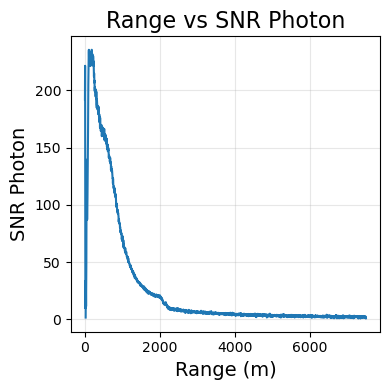

In [19]:
plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_Photon",
    yscale="linear",
    title="Range vs SNR Photon",
    xlabel="Range (m)",
    ylabel="SNR Photon",
    outfile="RawFilePicforExample/Prototype/range_vs_Photon_SNR.png",
)

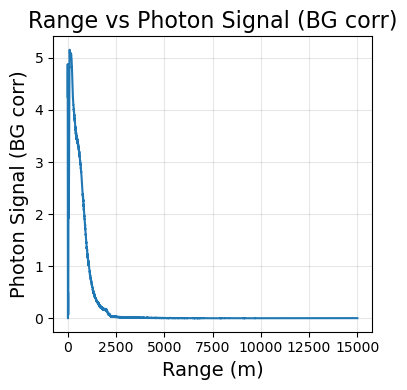

In [20]:
plot_xy(
    df,
    xcol="range_m",
    ycol="Photon_per_bin_bg_corr",
    yscale="linear",
    title="Range vs Photon Signal (BG corr)",
    xlabel="Range (m)",
    ylabel="Photon Signal (BG corr)",
    outfile="RawFilePicforExample/Prototype/range_vs_Photon_Signal_BG_corr.png",
)

In [21]:
# plot_xy(
#     df,
#     xcol="range_m",
#     ycol="photon_APcorr_counts",
#     yscale="linear",
#     title="Range vs Photon Signal (AP corr)",
#     xlabel="Range (m)",
#     ylabel="Photon Signal (AP corr)",
#     outfile="RawFilePicforExample/Prototype/range_vs_Photon_Signal_AP_corr.png",
# )

In [22]:
# x_min = config["deadtime_region_begin"]
# x_max = config["deadtime_region_end"]

# df_sel = df[df["range_m"].between(x_min, x_max)]


In [23]:
# thr_min = config["min_toggle_rate"]
# thr_max = config["max_toggle_rate"]

# deadtime_region = df_sel["photon_counting"].between(thr_min, thr_max, inclusive="both")

# # label contiguous True blocks
# grp = (deadtime_region != deadtime_region.shift()).cumsum()

# # keep only True blocks, then summarize each block
# intervals = (
#     df_sel.loc[deadtime_region, ["range_m", "photon_counting"]]
#       .groupby(grp[deadtime_region])
#       .agg(
#           start_range=("range_m", "min"),
#           end_range=("range_m", "max"),
#           n_bins=("range_m", "size"),
#           pc_min=("photon_counting", "min"),
#           pc_max=("photon_counting", "max"),
#       )
# )

# intervals


In [24]:
# fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot(
#     df["range_m"],
#     df["photon_counting"],
#     label="Afterpulse-corrected photon rate",
# )

# for i, row in intervals.iterrows():
#     ax.axvspan(
#         row["start_range"],
#         row["end_range"],
#         alpha=0.25,
#         label="Dead-time interval" if i == 0 else None,
#     )

# ax.set_xlabel("Range (m)")
# ax.set_ylabel("Photon counting")
# ax.grid(True, alpha=0.3)
# ax.legend()
# plt.tight_layout()
# plt.show()


In [25]:
# 1) build counts-per-bin after bg + afterpulse correction
df["photon_APcorr_counts"] = df["Photon_per_bin_bg_corr"] - df["afterpulse_counts_per_bin"]

bin_width_s  = config["bin_width_ns"] * 1e-9
dead_time_s  = config["dead_time_ns"] * 1e-9

# 2) mask: saturated region defined in MHz
sat = df["photon_counting"] >= config["max_toggle_rate"]

# 3) validity for correction (denominator must stay positive)
#    ratio = N_obs * tau / dt
ratio = df["photon_APcorr_counts"] * dead_time_s / bin_width_s
denom = 1.0 - ratio
valid = (~sat) & np.isfinite(ratio) & (denom > 1e-6) & (df["photon_APcorr_counts"] >= 0)

# 4) apply dead-time correction ONCE
df["photon_deadtime_corr_counts"] = np.where(
    valid,
    df["photon_APcorr_counts"] / denom,
    np.nan
)


In [26]:
df["photon_APcorr_counts"] = df["Photon_per_bin_bg_corr"]-df["afterpulse_counts_per_bin"]
bin_width_s = config["bin_width_ns"] * 1e-9
dead_time_s = config["dead_time_ns"] * 1e-9

df["photon_deadtime_counts"] = (
    df["photon_APcorr_counts"]
    / (1 - df["photon_APcorr_counts"] * dead_time_s / bin_width_s)
)

#It will invalid in this case
ratio = df["photon_deadtime_counts"] * dead_time_s / bin_width_s

eps = 1e-6
valid = ratio < (1 - eps)

df["photon_deadtime_corr"] = np.where(
    valid,
    df["photon_deadtime_counts"] / (1 - ratio),
    np.nan
)


In [27]:
df.head()

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,analog_bg_corr,Photon_per_bin_bg_corr,afterpulse_raw,afterpulse_counts_per_bin,photon_APcorr_counts,photon_deadtime_corr_counts,photon_deadtime_counts,photon_deadtime_corr
0,0,0.00,32.5068,0.186314,170.28000,0.887414,0.0,174.473201,191.883383,4.257000,28.614396,4.255895,0.0,0.0,4.255895,NaN,8.883505,NaN
1,1,3.75,72.2066,0.364441,195.29500,0.882275,0.0,198.129738,221.353886,4.882375,68.314196,4.881270,0.0,0.0,4.881270,NaN,12.126400,NaN
2,2,7.50,267.2780,2.211960,119.36400,1.323580,0.0,120.833107,90.182686,2.984100,263.385596,2.982995,0.0,0.0,2.982995,NaN,4.698508,11.057847
3,3,11.25,473.4230,0.081785,1.67434,0.167204,0.0,5788.600410,10.013756,0.041858,469.530596,0.040754,0.0,0.0,0.040754,0.040958,0.040958,0.041164
4,4,15.00,473.4570,0.000000,0.00000,0.000000,0.0,inf,NaN,0.000000,469.564596,-0.001105,0.0,0.0,-0.001105,NaN,-0.001105,-0.001104


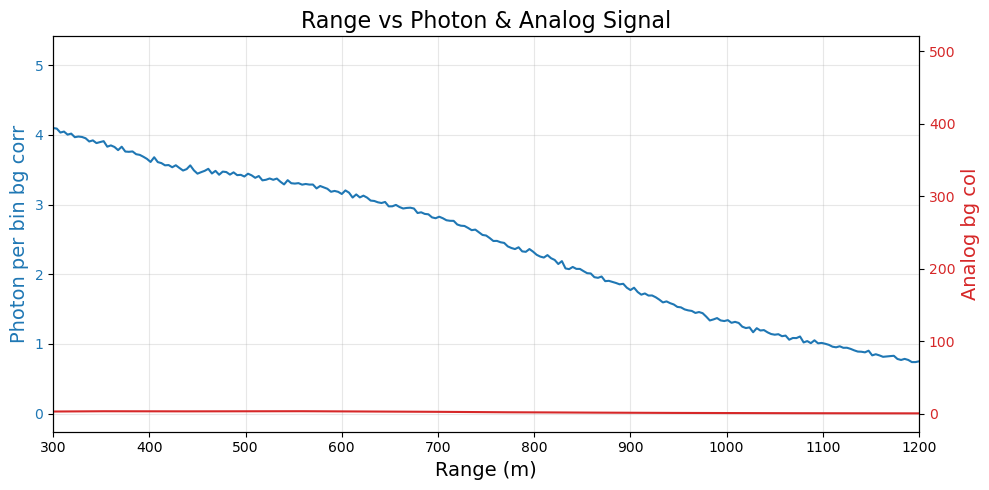

In [28]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["Photon_per_bin_bg_corr"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon per bin bg corr", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog_bg_corr"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog bg col", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

# ZOOM HERE
ax1.set_xlim(300, 1200)   # try 0–2000 m first

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [29]:
# m_overlap = df[(df["range_m"] >= config["overlap_r1_m"]) & (df["range_m"] <= config["overlap_r2_m"])]
m_overlap = df[
    (df["range_m"] >= config["overlap_r1_m"]) &
    (df["range_m"] <= config["overlap_r2_m"]) &
    np.isfinite(df["photon_deadtime_corr"]) &
    np.isfinite(df["analog_bg_corr"])
]


# x = m_overlap["analog_bg_corr"].to_numpy()
# y = m_overlap["photon_APcorr_counts"].to_numpy()

# k_scale, b_offset, r, *_ = linregress(x, y)

x = m_overlap["photon_deadtime_corr_counts"].to_numpy()
y = m_overlap["analog_bg_corr"].to_numpy()

k_scale, b_offset, r, *_ = linregress(x, y)

print("k_scale =", k_scale,
      "b_offset =", b_offset,
      "R^2 =", r**2)

df["analog_scaled_for_glue"] = k_scale * df["analog_bg_corr"] + b_offset

ValueError: Inputs must not be empty.

In [ ]:
r1 = config["overlap_r1_m"]
r2 = config["overlap_r2_m"]

mask_r = df["range_m"].between(r1, r2, inclusive="both")
print("range_m between r1-r2:", int(mask_r.sum()))
print("r1,r2:", r1, r2)
print("range_m min/max:", df["range_m"].min(), df["range_m"].max())

mask_pc = np.isfinite(df["photon_deadtime_corr_counts"])
mask_an = np.isfinite(df["analog_bg_corr"])

print("finite photon_deadtime_corr_counts:", int(mask_pc.sum()))
print("finite analog_bg_corr:", int(mask_an.sum()))
print("finite BOTH in overlap:", int((mask_r & mask_pc & mask_an).sum()))

# optional: check saturation / validity ratio if you have it
if "deadtime_ratio" in df.columns:
    m = df.loc[mask_r, "deadtime_ratio"]
    print("deadtime_ratio in overlap: min/max:", np.nanmin(m), np.nanmax(m))

good = np.isfinite(df["photon_deadtime_corr_counts"]) & np.isfinite(df["analog_bg_corr"])
r_good = df.loc[good, "range_m"]

print("Both-finite bins:", int(good.sum()))
print("Both-finite range min/max:", float(r_good.min()), float(r_good.max()))


In [150]:
from scipy.stats import linregress
import numpy as np

r1, r2 = 2000, 5000  # try this
mask = (
    df["range_m"].between(r1, r2) &
    np.isfinite(df["photon_deadtime_corr_counts"]) &
    np.isfinite(df["analog_bg_corr"])
)

m_overlap = df.loc[mask].copy()
print("Overlap points:", len(m_overlap))

x = m_overlap["photon_deadtime_corr_counts"].to_numpy()
y = m_overlap["analog_bg_corr"].to_numpy()

if len(x) < 2:
    raise ValueError("No valid overlap points. Use the interval-finder to choose a continuous good block.")

k_scale, b_offset, r, *_ = linregress(x, y)

print("k_scale =", k_scale, "b_offset =", b_offset, "R^2 =", r**2)

# df["photon_scaled_for_glue"] = k_scale * df["photon_deadtime_corr_counts"] + b_offset

PC = df["photon_deadtime_corr_counts"]          # counts/bin (NaN where invalid)
AN = df["analog_bg_corr"]                      # analog units

df["photon_scaled_for_glue"] = k_scale * PC + b_offset   # now in analog units


df["merged"] = np.where(
    np.isfinite(df["photon_scaled_for_glue"]),
    df["photon_scaled_for_glue"],
    df["analog_bg_corr"]
)


Overlap points: 799
k_scale = 0.6171720547584494 b_offset = -0.1989442575683439 R^2 = 0.8352826506869756


In [152]:
good = (
    np.isfinite(df["photon_deadtime_corr_counts"]) &
    np.isfinite(df["analog_bg_corr"])
)

grp = (good != good.shift()).cumsum()

intervals = (
    df.loc[good, ["range_m", "analog_bg_corr", "photon_deadtime_corr_counts"]]
      .groupby(grp[good])
      .agg(
          start=("range_m", "min"),
          end=("range_m", "max"),
          n_bins=("range_m", "size"),
          an_p50=("analog_bg_corr", "median"),
          pc_p50=("photon_deadtime_corr_counts", "median"),
      )
      .sort_values("n_bins", ascending=False)
)

print(intervals.head(10))


      start      end  n_bins      an_p50    pc_p50
14  1653.75  4848.75     853   -0.191814  0.012728
16  4856.25  5358.75     135   -0.178504  0.003093
18  5366.25  5595.00      62   -0.170884  0.002663
20  5602.50  5621.25       6   -0.168344  0.003082
2     11.25    11.25       1  469.530596  0.040958
4     18.75    18.75       1  469.564596  0.000570
6     30.00    30.00       1  469.564596  0.066404
8   1620.00  1620.00       1   -0.013304  0.253934
10  1638.75  1638.75       1   -0.019174  0.242823
12  1646.25  1646.25       1   -0.025594  0.252154


In [154]:
# blend_r1_m = config["overlap_r1_m"] - 100   # or -50
# blend_r2_m = config["overlap_r2_m"] + 100   # or +50

blend_r1_m = 1653.75 - 100   # or -50
blend_r2_m = 4848.75 + 100   # or +50

r = df["range_m"].to_numpy()

w = np.zeros_like(r, dtype=float)

# r > r2  -> w = 1
w[r > blend_r2_m] = 1.0

# r1 <= r <= r2 -> cosine blend
m = (r >= blend_r1_m) & (r <= blend_r2_m)
w[m] = 0.5 * (1.0 - np.cos(np.pi * (r[m] - blend_r1_m) / (blend_r2_m - blend_r1_m)))

df["weight_w"] = w

In [156]:
PCS = df["photon_scaled_for_glue"].to_numpy()
AN  = df["analog_bg_corr"].to_numpy()
w   = df["weight_w"].to_numpy()

merged = (1.0 - w) * AN + w * PCS

# if photon is NaN, force merged to analog (don’t let NaN spread)
bad_pc = ~np.isfinite(PCS)
merged[bad_pc] = AN[bad_pc]

df["merged_analog_units"] = merged

x = df["range2_corrected_counts"].to_numpy()
ref = np.nanpercentile(x, 99)   # or choose a clean far-range window
df["range2_norm"] = df["range2_corrected_counts"] / ref


KeyError: 'range2_corrected_counts'

In [148]:
df["merged_counts_per_bin"] = (
    (1.0 - df["weight_w"]) * df["analog_scaled_for_glue"]
    + df["weight_w"] * df["photon_APcorr_counts"]
)

#real???
df["range2_corrected_counts"] = (
    df["merged_counts_per_bin"] * df["range_m"]**2
)
df["range2_norm"] = (
    df["range2_corrected_counts"] /
    df["range2_corrected_counts"].max()
)


KeyError: 'analog_scaled_for_glue'

KeyError: 'merged_counts_per_bin'

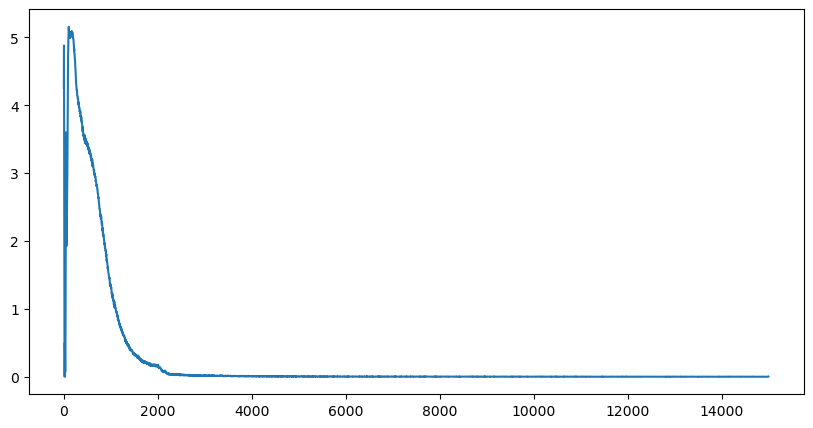

In [63]:
fig, ax1 = plt.subplots(figsize=(10,5))

# --- Left y-axis: Photon + Merged ---
ax1.plot(
    df["range_m"],
    df["Photon_per_bin_bg_corr"],
    color="tab:blue",
    label="Photon_per_bin_bg_corr"
)

ax1.plot(
    df["range_m"],
    df["merged_counts_per_bin"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Merged (glued)"
)

ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Counts per bin", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# --- Right y-axis: Analog ---
ax2 = ax1.twinx()
ax2.plot(
    df["range_m"],
    df["analog_scaled_for_glue"],
    color="tab:red",
    label="analog_scaled_for_glue"
)
ax1.axvspan(
    blend_r1_m,
    blend_r2_m,
    color="gray",
    alpha=0.2,
    label="Blend region"
)
ax1.set_xlim(0, 4000) 
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

# ax1.set_xlim(100, 1500)   # try 0–2000 m first

# --- Legend (combine both axes) ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Range vs Photon, Analog, and Merged Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
fig, ax1 = plt.subplots(figsize=(10,5))

# --- Left y-axis: Photon + Merged ---
ax1.plot(
    df["range_m"],
    df["Photon_per_bin_bg_corr"],
    color="tab:blue",
    label="Photon"
)

# ax1.plot(
#     df["range_m"],
#     df["merged_counts_per_bin"],
#     color="black",
#     linestyle="--",
#     linewidth=2,
#     label="Merged (glued)"
# )

ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Counts per bin", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# --- Right y-axis: Analog ---
# ax2 = ax1.twinx()
# ax2.plot(
#     df["range_m"],
#     df["analog_scaled_for_glue"],
#     color="tab:red",
#     label="Analog"
# )
# ax1.axvspan(
#     blend_r1_m,
#     blend_r2_m,
#     color="gray",
#     alpha=0.2,
#     label="Blend region"
# )
# ax1.set_xlim(0, 4000) 
# ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
# ax2.tick_params(axis="y", labelcolor="tab:red")

# ax1.set_xlim(100, 1500)   # try 0–2000 m first

# --- Legend (combine both axes) ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Range vs Photon Count per bin", fontsize=16)
plt.tight_layout()
plt.show()


In [66]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,analog_bg_corr,Photon_per_bin_bg_corr,afterpulse_raw,afterpulse_counts_per_bin,photon_APcorr_counts,photon_deadtime_corr_counts,photon_deadtime_counts,photon_deadtime_corr
0,0,0.00,32.50680,0.186314,170.280000,0.887414,0.0,174.473201,191.883383,4.257000,28.614396,4.255895,0.0,0.0,4.255895,NaN,8.883505,NaN
1,1,3.75,72.20660,0.364441,195.295000,0.882275,0.0,198.129738,221.353886,4.882375,68.314196,4.881270,0.0,0.0,4.881270,NaN,12.126400,NaN
2,2,7.50,267.27800,2.211960,119.364000,1.323580,0.0,120.833107,90.182686,2.984100,263.385596,2.982995,0.0,0.0,2.982995,NaN,4.698508,11.057847
3,3,11.25,473.42300,0.081785,1.674340,0.167204,0.0,5788.600410,10.013756,0.041858,469.530596,0.040754,0.0,0.0,0.040754,0.040958,0.040958,0.041164
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,469.564596,-0.001105,0.0,0.0,-0.001105,NaN,-0.001105,-0.001104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,3.95379,0.000000,0.033487,0.000000,0.0,inf,inf,0.000837,0.061386,-0.000268,NaN,NaN,NaN,NaN,NaN,NaN
3996,3996,14985.00,3.95427,0.000000,0.066974,0.000000,0.0,inf,inf,0.001674,0.061866,0.000570,NaN,NaN,NaN,NaN,NaN,NaN
3997,3997,14988.75,3.95419,0.000000,0.050230,0.000000,0.0,inf,inf,0.001256,0.061786,0.000151,NaN,NaN,NaN,NaN,NaN,NaN
3998,3998,14992.50,3.95484,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.062436,-0.001105,NaN,NaN,NaN,NaN,NaN,NaN


KeyError: 'merged_counts_per_bin'

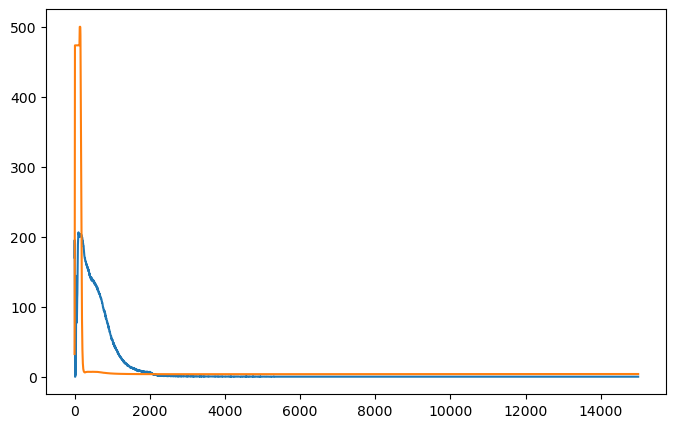

In [68]:
def plot_vs_range(
    df,
    ycols,                  # list ของ column ที่จะ plot
    *,
    xcol="range_m",
    labels=None,            # list ของ label (optional)
    title=None,
    xlabel="Range (m)",
    ylabel=None,
    yscale="linear",        # "linear" or "log"
    xlim=None,
    ylim=None,
    figsize=(8,5),
):
    plt.figure(figsize=figsize)

    if labels is None:
        labels = ycols

    for y, lab in zip(ycols, labels):
        plt.plot(df[xcol], df[y], label=lab)

    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)

    plt.yscale(yscale)

    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_vs_range(
    df,
    ycols=[
        "photon_counting",
        "analog",
        "merged_counts_per_bin",
    ],
    labels=[
        "Photon",
        "Analog",
        "Merged (glued)",
    ],
    ylabel="Counts per bin",
    yscale="linear",
    xlim=(0, 4000),
    title="Merged Signal vs Photon",
)



KeyError: 'analog_scaled_for_glue'

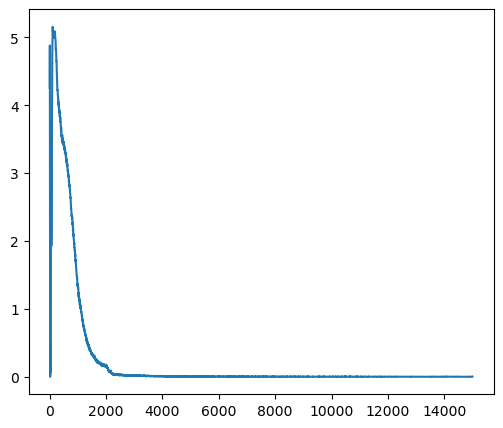

In [70]:
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(df["range_m"], df["Photon_per_bin_bg_corr"], label="Photon (bg corr)")
ax.plot(df["range_m"], df["analog_scaled_for_glue"], label="Analog (scaled)")
ax.plot(df["range_m"], df["merged_counts_per_bin"], "--", linewidth=2, label="Merged (glued)")

ax.axvspan(blend_r1_m, blend_r2_m, alpha=0.2, label="Blend region")
ax.set_xlabel("Range (m)")
ax.set_xlim(0, 2500) 
ax.set_ylabel("Counts per bin")
ax.set_yscale("log")
ax.set_ylim(1e-3, None)   # avoid log(0) issues
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


In [72]:
plot_xy(
    df,
    xcol="range_m",
    ycol="merged_counts_per_bin",
    yscale="linear",
    title="Range vs Merged Counts per Bin",
    xlabel="Range (m)",
    ylabel="Merged Counts per Bin",
    outfile="RawFilePicforExample/Prototype/range_vs_merged_counts_per_bin.png",
)

KeyError: 'merged_counts_per_bin'

<Figure size 400x400 with 0 Axes>

In [74]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_norm",
    yscale="linear",
    title="Range vs Merged Signal (Range² Corrected)",
    xlabel="Range (m)",
    ylabel="Range² Corrected Counts",
    outfile="RawFilePicforExample/Prototype/range_vs_merged_counts_per_bin.png",
)

KeyError: 'range2_norm'

<Figure size 400x400 with 0 Axes>

In [76]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_norm",
    yscale="linear",
    title="Range vs Range² Normalized",
    xlabel="Range (m)",
    ylabel="Range² Normalized",
    outfile="RawFilePicforExample/Prototype/range_vs_Range2_Normalized.png",
)

KeyError: 'range2_norm'

<Figure size 400x400 with 0 Axes>

In [78]:
cols = [
    "analog_bg_corr",
    "photon_APcorr_counts",
    "photon_deadtime_corr_counts",
    "photon_scaled_for_glue",
    "weight_w",
    "merged_analog_units",
]
for c in cols:
    if c in df.columns:
        x = df[c].to_numpy()
        print(c,
              "finite", np.isfinite(x).sum(),
              "min", np.nanmin(x),
              "p1", np.nanpercentile(x, 1),
              "p50", np.nanpercentile(x, 50),
              "p99", np.nanpercentile(x, 99),
              "max", np.nanmax(x))


analog_bg_corr finite 4000 min -0.20087442610652628 p1 -0.1993845261065263 p50 -0.07894442610652641 p99 446.03987557388785 max 496.1075955738935
photon_APcorr_counts finite 1500 min -0.0015128498818454612 p1 0.0009882126181545389 p50 0.018568787618154538 p99 5.042449648693155 max 5.157120287618155
photon_deadtime_corr_counts finite 1062 min 0.00015104541062415871 p1 0.0009883321640699514 p50 0.00979023044652996 p99 0.232357379802834 max 0.2566046527010543


In [80]:
def plot_xy_only_SNR_analog(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()
    plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_analog",
    yscale="linear",
    title="Range vs SNR Analog",
    xlabel="Range (m)",
    ylabel="SNR Analog",
    outfile="RawFilePicforExample/Prototype/range_vs_SNR_analog.png",
)

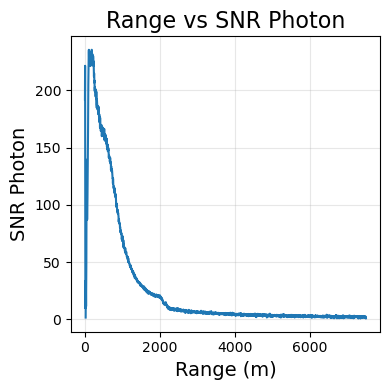

In [82]:
plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_Photon",
    yscale="linear",
    title="Range vs SNR Photon",
    xlabel="Range (m)",
    ylabel="SNR Photon",
    outfile="RawFilePicforExample/Prototype/range_vs_SNR_Photon.png",
)

In [84]:
m_overlap = (
    (df["range_m"] >= config["overlap_r1_m"]) &
    (df["range_m"] <= config["overlap_r2_m"])
)

ratio = (
    df.loc[m_overlap, "analog_scaled_for_glue"] /
    df.loc[m_overlap, "photon_APcorr_counts"]
)

#On average, the scaled analog signal is (ratio mean - 1) * 100 % higher than the photon signal in the overlap region.
print("ratio mean:", ratio.mean())
#How much the ratio fluctuates from bin to bin around the mean.
print("ratio std :", ratio.std())

KeyError: 'analog_scaled_for_glue'

In [ ]:
df["photon_deadtime_corr"].max()

In [134]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,analog_bg_corr,Photon_per_bin_bg_corr,afterpulse_raw,afterpulse_counts_per_bin,photon_APcorr_counts,photon_deadtime_corr_counts,photon_deadtime_counts,photon_deadtime_corr
0,0,0.00,32.50680,0.186314,170.280000,0.887414,0.0,174.473201,191.883383,4.257000,28.614396,4.255895,0.0,0.0,4.255895,NaN,8.883505,NaN
1,1,3.75,72.20660,0.364441,195.295000,0.882275,0.0,198.129738,221.353886,4.882375,68.314196,4.881270,0.0,0.0,4.881270,NaN,12.126400,NaN
2,2,7.50,267.27800,2.211960,119.364000,1.323580,0.0,120.833107,90.182686,2.984100,263.385596,2.982995,0.0,0.0,2.982995,NaN,4.698508,11.057847
3,3,11.25,473.42300,0.081785,1.674340,0.167204,0.0,5788.600410,10.013756,0.041858,469.530596,0.040754,0.0,0.0,0.040754,0.040958,0.040958,0.041164
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,469.564596,-0.001105,0.0,0.0,-0.001105,NaN,-0.001105,-0.001104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,3.95379,0.000000,0.033487,0.000000,0.0,inf,inf,0.000837,0.061386,-0.000268,NaN,NaN,NaN,NaN,NaN,NaN
3996,3996,14985.00,3.95427,0.000000,0.066974,0.000000,0.0,inf,inf,0.001674,0.061866,0.000570,NaN,NaN,NaN,NaN,NaN,NaN
3997,3997,14988.75,3.95419,0.000000,0.050230,0.000000,0.0,inf,inf,0.001256,0.061786,0.000151,NaN,NaN,NaN,NaN,NaN,NaN
3998,3998,14992.50,3.95484,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.062436,-0.001105,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_norm",
    yscale="linear",
    title="Range vs Photon Signal (per bin)",
    xlabel="Range (m)",
    ylabel="Photon Signal (per bin)",
    outfile="RawFilePicforExample/Prototype/range_vs_Photon_Signal_per_bin.png",
)

KeyError: 'range2_norm'

<Figure size 400x400 with 0 Axes>

In [132]:
#MiniMPL
MiniMPL = pd.read_csv("MPL_5038_202601050000.csv")
MiniMPL

,range_raw,range (m) for NRB,range (m),copol_raw,copol_snr,copol_nrb,pbls,Normalize copol nrb
0,0.029979,29.979246,119.91698,22.973406,74635.140000,0.217418,2.428319,0.919494
1,0.059958,59.958490,149.89623,9.440220,30666.166000,0.235153,NaN,0.994498
2,0.089938,89.937740,179.87548,8.520437,27675.664000,0.236075,NaN,0.998398
3,0.119917,119.916980,209.85472,8.234554,26750.950000,0.213818,NaN,0.904269
4,0.149896,149.896230,239.83397,8.518830,27674.977000,0.192532,NaN,0.814248
...,...,...,...,...,...,...,...,...
995,29.859330,29859.330000,NaN,0.000625,-0.257925,NaN,NaN,NaN
996,29.889309,29889.309000,NaN,0.000729,0.036500,NaN,NaN,NaN
997,29.919287,29919.287000,NaN,0.000699,-0.039971,NaN,NaN,NaN
998,29.949266,29949.266000,NaN,0.000580,-0.416790,NaN,NaN,NaN


In [106]:
# Select + rename columns
MiniMPL_for_process = pd.DataFrame({
    "range_raw": MiniMPL["range_raw"],
    "range (m) for NRB": MiniMPL["range_raw"]*1000,
    "range (m)": MiniMPL["range_nrb"]*1000,
    "copol_raw": MiniMPL["copol_raw"],
    "copol_snr": MiniMPL["copol_snr"],
    "copol_nrb": MiniMPL["copol_nrb"],
    "pbls": MiniMPL["pbls"],
    "Normalize copol nrb": MiniMPL["copol_nrb"]/MiniMPL["copol_nrb"].max(),
})

# Save to CSV
MiniMPL_for_process.to_csv("MPL_5038_202601050000.csv", index=False)

In [110]:
MiniMPL_for_process = pd.read_csv("MPL_5038_202601050000.csv")
MiniMPL_for_process

,range_raw,range (m) for NRB,range (m),copol_raw,copol_snr,copol_nrb,pbls,Normalize copol nrb
0,0.029979,29.979246,119.91698,22.973406,74635.140000,0.217418,2.428319,0.919494
1,0.059958,59.958490,149.89623,9.440220,30666.166000,0.235153,NaN,0.994498
2,0.089938,89.937740,179.87548,8.520437,27675.664000,0.236075,NaN,0.998398
3,0.119917,119.916980,209.85472,8.234554,26750.950000,0.213818,NaN,0.904269
4,0.149896,149.896230,239.83397,8.518830,27674.977000,0.192532,NaN,0.814248
...,...,...,...,...,...,...,...,...
995,29.859330,29859.330000,NaN,0.000625,-0.257925,NaN,NaN,NaN
996,29.889309,29889.309000,NaN,0.000729,0.036500,NaN,NaN,NaN
997,29.919287,29919.287000,NaN,0.000699,-0.039971,NaN,NaN,NaN
998,29.949266,29949.266000,NaN,0.000580,-0.416790,NaN,NaN,NaN


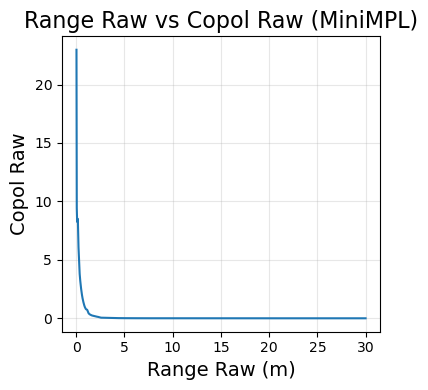

In [112]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_raw",
    yscale="linear",
    title="Range Raw vs Copol Raw (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol Raw",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_Raw(MiniMPL).png",
)

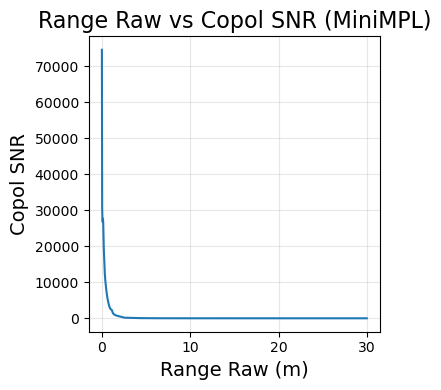

In [114]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_snr",
    yscale="linear",
    title="Range Raw vs Copol SNR (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol SNR",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_SNR(MiniMPL).png",
)

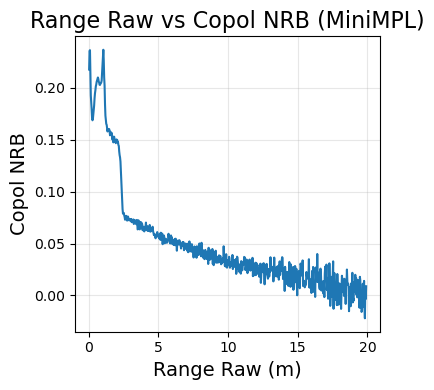

In [116]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_nrb",
    yscale="linear",
    title="Range Raw vs Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol NRB",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_NRB(MiniMPL).png",
)

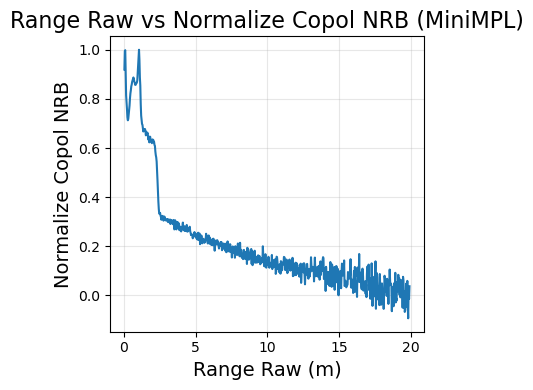

In [118]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="Normalize copol nrb",
    yscale="linear",
    title="Range Raw vs Normalize Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Normalize Copol NRB",
    outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Normalize_copol_nrb(MiniMPL).png",
)

KeyError: 'range2_norm'

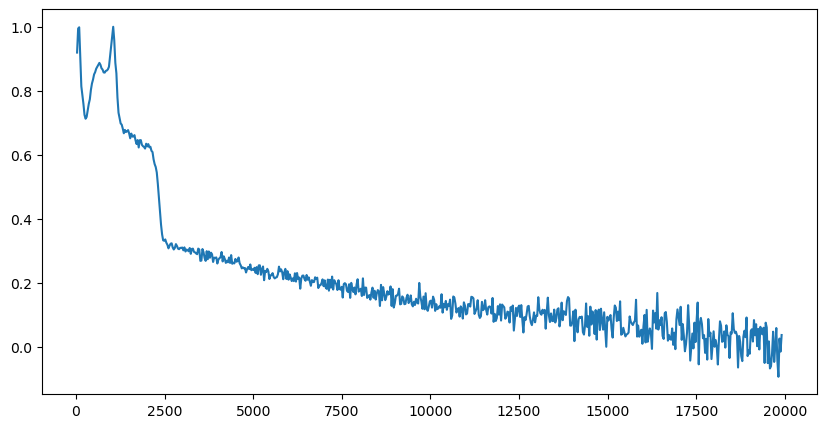

In [120]:
plt.figure(figsize=(10, 5))

plt.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize copol nrb"],
    label="MiniMPL Normalize copol nrb",
)

plt.plot(
    df["range_m"],
    df["range2_norm"],
    label="Range² normalized",
)
plt.xlim(0, 7500)   # example: 0–8 km
plt.xlabel("Range (m)")
plt.ylabel("Normalized signal")
plt.title("Comparison of Normalized Signals vs Range")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'range2_norm'

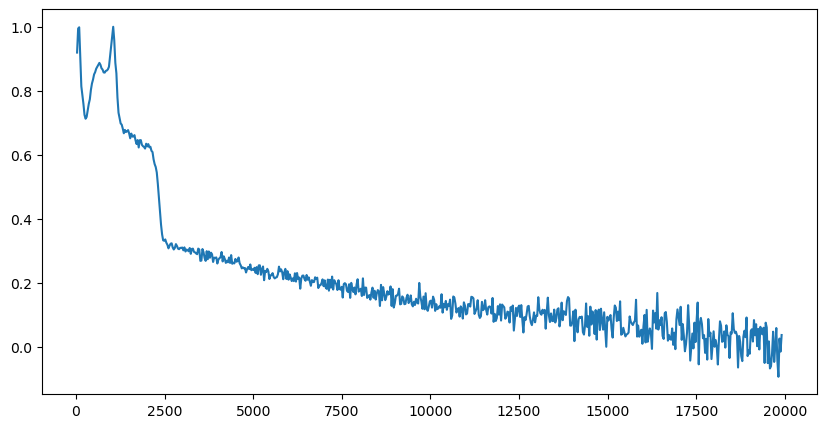

In [130]:
plt.figure(figsize=(10, 5))

plt.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize copol nrb"],
    label="MiniMPL Normalize copol nrb",
)

plt.plot(
    df["range_m"]-70,
    df["range2_norm"]+0.15,
    label="Range² normalized",
)
plt.xlim(0, 7500)   # example: 0–8 km
plt.xlabel("Range (m)")
plt.ylabel("Normalized signal")
plt.title("Comparison of Normalized Signals vs Range")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [124]:
#Excelcode
Excel_code = pd.read_csv("/Users/thunthita/Lidarforiypnb/LIDar/csvfiles/05-01-2026/P'BOX-TR-00.05-05.csv")
Excel_code

FileNotFoundError: [Errno 2] No such file or directory: "/Users/thunthita/Lidarforiypnb/LIDar/csvfiles/05-01-2026/P'BOX-TR-00.05-05.csv"

KeyError: 'range2_norm'

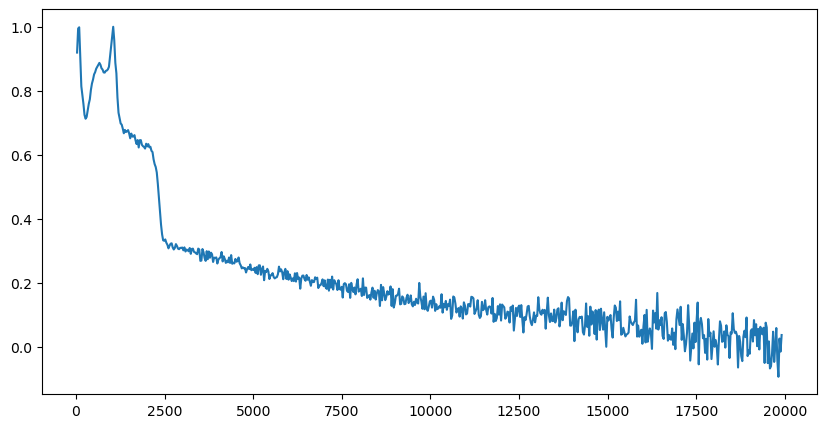

In [126]:
df_0_1500 = df[(df["range_m"] >= 0) & (df["range_m"] <= 1500)]

plt.figure(figsize=(10, 5))

plt.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize copol nrb"],
    label="MiniMPL Normalize copol nrb",
)

plt.plot(
    df_0_1500["range_m"],
    df_0_1500["range2_norm"],
    label="Range² normalized",
)
plt.plot(
    Excel_code["range_m"],
    Excel_code["Normallize R^2_range_squared"],
    label="Range² normalized from P'Box",
)
plt.xlim(0, 5621.25)   # example: 0–8 km
plt.xlabel("Range (m)")
plt.ylabel("Normalized signal")
plt.title("Comparison of Normalized Signals vs Range")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [128]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,analog_bg_corr,Photon_per_bin_bg_corr,afterpulse_raw,afterpulse_counts_per_bin,photon_APcorr_counts,photon_deadtime_corr_counts,photon_deadtime_counts,photon_deadtime_corr
0,0,0.00,32.50680,0.186314,170.280000,0.887414,0.0,174.473201,191.883383,4.257000,28.614396,4.255895,0.0,0.0,4.255895,NaN,8.883505,NaN
1,1,3.75,72.20660,0.364441,195.295000,0.882275,0.0,198.129738,221.353886,4.882375,68.314196,4.881270,0.0,0.0,4.881270,NaN,12.126400,NaN
2,2,7.50,267.27800,2.211960,119.364000,1.323580,0.0,120.833107,90.182686,2.984100,263.385596,2.982995,0.0,0.0,2.982995,NaN,4.698508,11.057847
3,3,11.25,473.42300,0.081785,1.674340,0.167204,0.0,5788.600410,10.013756,0.041858,469.530596,0.040754,0.0,0.0,0.040754,0.040958,0.040958,0.041164
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,469.564596,-0.001105,0.0,0.0,-0.001105,NaN,-0.001105,-0.001104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,3.95379,0.000000,0.033487,0.000000,0.0,inf,inf,0.000837,0.061386,-0.000268,NaN,NaN,NaN,NaN,NaN,NaN
3996,3996,14985.00,3.95427,0.000000,0.066974,0.000000,0.0,inf,inf,0.001674,0.061866,0.000570,NaN,NaN,NaN,NaN,NaN,NaN
3997,3997,14988.75,3.95419,0.000000,0.050230,0.000000,0.0,inf,inf,0.001256,0.061786,0.000151,NaN,NaN,NaN,NaN,NaN,NaN
3998,3998,14992.50,3.95484,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.062436,-0.001105,NaN,NaN,NaN,NaN,NaN,NaN
